In [1]:
import os 
import pandas as pd 

In [2]:
sleep_df = pd.read_csv('data/compliant_user_sleep.csv', index_col = 0)
sleep_df

,pid,sleep_time,wakeup_time,sleep_duration,measured_date,enough_sleep,sleep_problems,sleep_time_decimal,sleep_duration_decimal,wakeup_time_decimal
1,alqt211037189551,06:01:00,06:17:00,00:16:00,2021-11-01,False,NaN,6.016667,0.266667,6.283333
2,alqt210824184578,05:21:00,06:00:00,00:39:00,2021-11-01,False,NaN,5.350000,0.650000,6.000000
3,alqt211057190816,13:29:00,13:40:00,00:11:00,2021-11-01,True,NaN,13.483333,0.183333,13.666667
4,alqt211057190816,13:29:00,13:40:00,00:11:00,2021-11-01,False,NaN,13.483333,0.183333,13.666667
5,alqt211038189357,05:45:00,06:32:00,00:47:00,2021-11-01,False,NaN,5.750000,0.783333,6.533333
...,...,...,...,...,...,...,...,...,...,...
1142020,alqt150230644249722,01:16:00,10:28:00,09:12:00,2024-02-18,False,--5.0,1.266667,9.200000,10.466667
1142021,alqt150230954258083,21:51:00,04:30:00,06:39:00,2024-02-18,False,watched TV too late--0.0,21.850000,6.650000,4.500000
1142022,alqt16075004,21:00:00,04:00:00,07:00:00,2024-02-18,True,--3.0,21.000000,7.000000,4.000000
1142023,alqt170410595,19:54:00,02:46:00,06:52:00,2024-02-18,False,--1.0,19.900000,6.866667,2.766667


In [3]:
sleep_df = sleep_df[(sleep_df['sleep_duration_decimal'] > 2) & 
                                 (sleep_df['sleep_duration_decimal'] < 14)]

In [4]:
sleep_df

,pid,sleep_time,wakeup_time,sleep_duration,measured_date,enough_sleep,sleep_problems,sleep_time_decimal,sleep_duration_decimal,wakeup_time_decimal
11,alqt211031188312,23:00:00,06:00:00,07:00:00,2021-11-01,True,NaN,23.000000,7.000000,6.000000
12,alqt211031188312,23:00:00,06:00:00,07:00:00,2021-11-01,False,NaN,23.000000,7.000000,6.000000
16,alqt211051189149,22:49:00,06:39:00,07:50:00,2021-11-01,False,NaN,22.816667,7.833333,6.650000
38,alqt210850183819,21:04:00,03:00:00,05:56:00,2021-11-01,True,NaN,21.066667,5.933333,3.000000
40,alqt211018190512,04:06:00,06:35:00,02:29:00,2021-11-01,True,NaN,4.100000,2.483333,6.583333
...,...,...,...,...,...,...,...,...,...,...
1142020,alqt150230644249722,01:16:00,10:28:00,09:12:00,2024-02-18,False,--5.0,1.266667,9.200000,10.466667
1142021,alqt150230954258083,21:51:00,04:30:00,06:39:00,2024-02-18,False,watched TV too late--0.0,21.850000,6.650000,4.500000
1142022,alqt16075004,21:00:00,04:00:00,07:00:00,2024-02-18,True,--3.0,21.000000,7.000000,4.000000
1142023,alqt170410595,19:54:00,02:46:00,06:52:00,2024-02-18,False,--1.0,19.900000,6.866667,2.766667


In [5]:
duplicate_cols = ['pid', 'measured_date', 'sleep_time', 'wakeup_time', 'sleep_duration']
duplicate_mask = sleep_df.duplicated(subset=duplicate_cols, keep='last')
sleep_df_deduped = sleep_df[~duplicate_mask]
sleep_df_deduped.shape

(714645, 10)

In [6]:
sleep_df_deduped

,pid,sleep_time,wakeup_time,sleep_duration,measured_date,enough_sleep,sleep_problems,sleep_time_decimal,sleep_duration_decimal,wakeup_time_decimal
12,alqt211031188312,23:00:00,06:00:00,07:00:00,2021-11-01,False,NaN,23.000000,7.000000,6.000000
16,alqt211051189149,22:49:00,06:39:00,07:50:00,2021-11-01,False,NaN,22.816667,7.833333,6.650000
38,alqt210850183819,21:04:00,03:00:00,05:56:00,2021-11-01,True,NaN,21.066667,5.933333,3.000000
40,alqt211018190512,04:06:00,06:35:00,02:29:00,2021-11-01,True,NaN,4.100000,2.483333,6.583333
41,alqt211046190038,20:00:00,05:57:00,09:57:00,2021-11-01,True,NaN,20.000000,9.950000,5.950000
...,...,...,...,...,...,...,...,...,...,...
1142020,alqt150230644249722,01:16:00,10:28:00,09:12:00,2024-02-18,False,--5.0,1.266667,9.200000,10.466667
1142021,alqt150230954258083,21:51:00,04:30:00,06:39:00,2024-02-18,False,watched TV too late--0.0,21.850000,6.650000,4.500000
1142022,alqt16075004,21:00:00,04:00:00,07:00:00,2024-02-18,True,--3.0,21.000000,7.000000,4.000000
1142023,alqt170410595,19:54:00,02:46:00,06:52:00,2024-02-18,False,--1.0,19.900000,6.866667,2.766667


In [7]:
from datetime import datetime, timedelta

clean_data = []

for (pid, date), group in sleep_df_deduped.groupby(['pid', 'measured_date']):
    if len(group) == 1:
        # Only one entry, keep it
        clean_data.append(group)
    else:
        # Simply keep the row with the highest index
        # This assumes that the index represents the order of entry
        last_entry = group.iloc[[group.index.argmax()]]
        clean_data.append(last_entry)

# Combine the results
cleaned_sleep_df = pd.concat(clean_data)

# Step 4: Apply your duration filter
final_sleep_df = cleaned_sleep_df[(cleaned_sleep_df['sleep_duration_decimal'] > 3) & 
                                 (cleaned_sleep_df['sleep_duration_decimal'] < 16)]

# Show the results
print(f"Original shape: {sleep_df.shape}")
print(f"After deduplication: {sleep_df_deduped.shape}")
print(f"After resolving overlaps: {cleaned_sleep_df.shape}")
print(f"After duration filtering: {final_sleep_df.shape}")

Original shape: (722794, 10)
After deduplication: (714645, 10)
After resolving overlaps: (690632, 10)
After duration filtering: (687146, 10)


In [8]:
sleep_df = final_sleep_df

In [9]:
sleep_df['sleep_problems'].value_counts()[:20]

sleep_problems
--- ''\n                                                                            235022
---\n- 'null'\n                                                                     121196
---\n- Woke up once or more\n                                                        27431
---\n- Insufficient sleep\n                                                          22860
---\n- Woke up once or more\n- Insufficient sleep\n                                  10060
Woke up once or more                                                                  8659
Insufficient sleep                                                                    6703
---\n- Difficult falling asleep\n- Woke up once or more\n- Insufficient sleep\n       3828
--- \n...\n                                                                           3762
---\n- Difficulty falling asleep\n- Woke up once or more\n- Insufficient sleep\n      3268
---\n- Difficult falling asleep\n- Woke up once or more\n                  

In [10]:
sleep_null = ["---\n- 'null'\n", "--- ''\n", "--4.0", "--5.0", "--3.0"]
sleep_df.loc[sleep_df['sleep_problems'].isin(sleep_null), 'sleep_problems'] = None

In [11]:
sleep_df.loc[:, 'sleep_problems_bool'] = ~sleep_df['sleep_problems'].isna()

/var/folders/dv/lndb9rrs2kv2v5g8cyfyx0wr0000gn/T/ipykernel_11141/539198569.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sleep_df.loc[:, 'sleep_problems_bool'] = ~sleep_df['sleep_problems'].isna()


In [12]:
sleep_df[['sleep_problems', 'sleep_problems_bool']].value_counts()[:30]

sleep_problems                                                                            sleep_problems_bool
---\n- Woke up once or more\n                                                             True                   27431
---\n- Insufficient sleep\n                                                               True                   22860
---\n- Woke up once or more\n- Insufficient sleep\n                                       True                   10060
Woke up once or more                                                                      True                    8659
Insufficient sleep                                                                        True                    6703
---\n- Difficult falling asleep\n- Woke up once or more\n- Insufficient sleep\n           True                    3828
--- \n...\n                                                                               True                    3762
---\n- Difficulty falling asleep\n- Woke up once or more\

In [13]:
sleep_df.drop(columns=['sleep_problems'], inplace=True)

/var/folders/dv/lndb9rrs2kv2v5g8cyfyx0wr0000gn/T/ipykernel_11141/1907150468.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sleep_df.drop(columns=['sleep_problems'], inplace=True)


In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering

# Step 1: Create sleep archetypes with one-hot encoding
def create_sleep_archetypes(df):
    # Make a copy to avoid modifying the original
    result = df.copy()
    
    # Sleep time archetypes
    result['early_sleeper'] = (result['sleep_time_decimal'] >= 19) & (result['sleep_time_decimal'] < 22)
    result['normal_sleeper'] = (result['sleep_time_decimal'] >= 22) & (result['sleep_time_decimal'] < 24)
    result['late_sleeper'] = (result['sleep_time_decimal'] >= 24) | (result['sleep_time_decimal'] < 3)
    result['irregular_sleeper'] = (result['sleep_time_decimal'] >= 3) & (result['sleep_time_decimal'] < 19)
    
    # Sleep duration archetypes
    result['short_sleep'] = result['sleep_duration_decimal'] < 6
    result['normal_sleep'] = (result['sleep_duration_decimal'] >= 6) & (result['sleep_duration_decimal'] < 9)
    result['long_sleep'] = result['sleep_duration_decimal'] >= 9
    
    # Wake time archetypes
    result['early_riser'] = (result['wakeup_time_decimal'] >= 3) & (result['wakeup_time_decimal'] < 7)
    result['normal_riser'] = (result['wakeup_time_decimal'] >= 7) & (result['wakeup_time_decimal'] < 9)
    result['late_riser'] = (result['wakeup_time_decimal'] >= 9) | (result['wakeup_time_decimal'] < 3)
    
    # Keep the cyclical encoding for time values
    result['sleep_time_sin'] = np.sin(result['sleep_time_decimal'] * 2 * np.pi / 24)
    result['sleep_time_cos'] = np.cos(result['sleep_time_decimal'] * 2 * np.pi / 24)
    result['wakeup_time_sin'] = np.sin(result['wakeup_time_decimal'] * 2 * np.pi / 24)
    result['wakeup_time_cos'] = np.cos(result['wakeup_time_decimal'] * 2 * np.pi / 24)
    
    # Add quality indicators
    result['satisfied'] = result['enough_sleep']
    result['has_problems'] = result['sleep_problems_bool']
    
    return result

# Create the augmented dataframe
sleep_augmented = create_sleep_archetypes(sleep_df)



In [15]:
import pandas as pd
import numpy as np

# For sleep_time percentiles that handle the midnight threshold correctly
# Adjust early morning hours (after midnight) to be "later" than evening hours
sleep_adjusted = sleep_augmented['sleep_time_decimal'].copy()
sleep_adjusted = sleep_adjusted.apply(lambda x: x + 24 if x < 12 else x)

# Calculate percentiles for adjusted sleep_time
sleep_percentiles = np.percentile(sleep_adjusted, [10, 25, 50, 75, 90])
# Convert back to the 0-24 hour format
sleep_percentiles = [x % 24 for x in sleep_percentiles]

# For wakeup_time percentiles
wakeup_adjusted = sleep_augmented['wakeup_time_decimal'].copy()
# Most wakeup times are in morning, but to be safe we'll handle potential PM times
wakeup_adjusted = wakeup_adjusted.apply(lambda x: x + 24 if 12 <= x < 18 else x)

# Calculate percentiles for wakeup_time
wakeup_percentiles = np.percentile(wakeup_adjusted, [10, 25, 50, 75, 90])
# Convert back to the 0-24 hour format
wakeup_percentiles = [x % 24 for x in wakeup_percentiles]

# Create a results DataFrame
percentile_df = pd.DataFrame({
    'Percentile': ['10th', '25th', '50th (Median)', '75th', '90th'],
    'Sleep Time (decimal)': sleep_percentiles,
    'Wakeup Time (decimal)': wakeup_percentiles
})

# Convert decimal hours to time format for better readability
def decimal_to_time(dec):
    hours = int(dec)
    minutes = int((dec - hours) * 60)
    return f"{hours:02d}:{minutes:02d}"

percentile_df['Sleep Time'] = percentile_df['Sleep Time (decimal)'].apply(decimal_to_time)
percentile_df['Wakeup Time'] = percentile_df['Wakeup Time (decimal)'].apply(decimal_to_time)

print(percentile_df[['Percentile', 'Sleep Time', 'Wakeup Time']])

      Percentile Sleep Time Wakeup Time
0           10th      21:30       05:04
1           25th      22:12       06:00
2  50th (Median)      23:00       06:45
3           75th      23:55       07:41
4           90th      01:00       08:45


In [16]:
pd.set_option('display.max_columns', 30)  # Shows up to 30 columns


In [17]:
import pandas as pd
import numpy as np

# Add adjusted sleep times to handle midnight crossover
sleep_augmented['sleep_time_adjusted'] = sleep_augmented['sleep_time_decimal'].apply(lambda x: x + 24 if x < 12 else x)

# Group by pid and calculate statistics
person_stats = sleep_augmented.groupby('pid').agg({
    # Count of records per person
    'sleep_time_decimal': ['count'],
    
    # Sleep time (using adjusted values to handle midnight properly)
    'sleep_time_adjusted': [
        lambda x: np.mean(x) % 24,  # Mean
        lambda x: np.median(x) % 24,  # Median
        lambda x: np.var(x)  # Variance
    ],
    
    # Wakeup time
    'wakeup_time_decimal': ['mean', 'median', 'var'],
    
    # Duration
    'sleep_duration_decimal': ['mean', 'median', 'var'],
    
    # Also include counts of boolean columns
    'satisfied': ['mean'],
    'has_problems': ['mean']
})

# Flatten the column names
person_stats.columns = ['_'.join(col).strip('_') for col in person_stats.columns.values]

# Rename columns for clarity
person_stats = person_stats.rename(columns={
    'sleep_time_decimal_count': 'count',
    'sleep_time_adjusted_<lambda_0>': 'sleep_time_mean',
    'sleep_time_adjusted_<lambda_1>': 'sleep_time_median',
    'sleep_time_adjusted_<lambda_2>': 'sleep_time_variance',
    'wakeup_time_decimal_mean': 'wakeup_time_mean',
    'wakeup_time_decimal_median': 'wakeup_time_median',
    'wakeup_time_decimal_var': 'wakeup_time_variance',
    'sleep_duration_decimal_mean': 'duration_mean',
    'sleep_duration_decimal_median': 'duration_median',
    'sleep_duration_decimal_var': 'duration_variance',
    'satisfied_mean': 'satisfaction_rate',
    'has_problems_mean': 'problem_rate'
})

# Reset index to make pid a regular column
person_stats = person_stats.reset_index()

# Calculate sleep regularity metrics
# 1. Standard deviation of sleep times as a regularity measure
person_stats['sleep_time_std'] = np.sqrt(person_stats['sleep_time_variance'])
person_stats['wakeup_time_std'] = np.sqrt(person_stats['wakeup_time_variance'])
person_stats['duration_std'] = np.sqrt(person_stats['duration_variance'])

# 2. Define category groups
sleeper_categories = ['early_sleeper', 'normal_sleeper', 'late_sleeper']
sleep_duration_categories = ['short_sleep', 'normal_sleep', 'long_sleep']
riser_categories = ['early_riser', 'normal_riser', 'late_riser']

# Function to find the most common category in a group
def get_most_common_category(group, categories):
    # Sum True values for each category
    category_counts = {cat: group[cat].sum() for cat in categories}
    # Find the category with the highest count
    max_count = max(category_counts.values())
    max_categories = [cat for cat, count in category_counts.items() if count == max_count]
    # Return the most common one (if there's a tie, take the first one)
    return max_categories[0] if max_categories else None

# Calculate the predominant type for each person in each category group
sleeper_type = {}
duration_type = {}
riser_type = {}

for pid, group in sleep_augmented.groupby('pid'):
    sleeper_type[pid] = get_most_common_category(group, sleeper_categories)
    duration_type[pid] = get_most_common_category(group, sleep_duration_categories)
    riser_type[pid] = get_most_common_category(group, riser_categories)

# Create DataFrames from the results
sleeper_df = pd.DataFrame.from_dict(sleeper_type, orient='index', columns=['sleeper_type'])
duration_df = pd.DataFrame.from_dict(duration_type, orient='index', columns=['duration_type'])
riser_df = pd.DataFrame.from_dict(riser_type, orient='index', columns=['riser_type'])

# Reset indices to prepare for merge
sleeper_df = sleeper_df.reset_index().rename(columns={'index': 'pid'})
duration_df = duration_df.reset_index().rename(columns={'index': 'pid'})
riser_df = riser_df.reset_index().rename(columns={'index': 'pid'})

# Merge with person_stats
person_stats = person_stats.merge(sleeper_df, on='pid')
person_stats = person_stats.merge(duration_df, on='pid')
person_stats = person_stats.merge(riser_df, on='pid')

# Define custom percentile thresholds
percentile_thresholds = [0, 5, 25, 50, 75, 95, 100]
percentile_labels = ['Bottom 5%', '5-25%', '25-50%', '50-75%', '75-95%', 'Top 5%']

# Function to create percentile buckets for a given column
def create_percentile_buckets(df, column_name):
    bucket_values = np.percentile(df[column_name].dropna(), percentile_thresholds[1:-1])
    bucket_categories = pd.cut(
        df[column_name], 
        bins=[-np.inf] + list(bucket_values) + [np.inf],
        labels=percentile_labels,
        include_lowest=True
    )
    return bucket_categories

# Apply to key columns
person_stats['sleep_time_mean_bucket'] = create_percentile_buckets(person_stats, 'sleep_time_mean')
person_stats['wakeup_time_mean_bucket'] = create_percentile_buckets(person_stats, 'wakeup_time_mean')
person_stats['duration_mean_bucket'] = create_percentile_buckets(person_stats, 'duration_mean')
person_stats['sleep_time_std_bucket'] = create_percentile_buckets(person_stats, 'sleep_time_std')

# Display the results
display(person_stats[['pid', 'count', 
                     'sleep_time_mean', 'sleep_time_median', 'sleep_time_std',
                     'wakeup_time_mean', 'wakeup_time_median', 'wakeup_time_std', 
                     'duration_mean', 'duration_median', 'duration_std',
                     'satisfaction_rate', 'problem_rate',
                     'sleeper_type', 'duration_type', 'riser_type']].head())

,pid,count,sleep_time_mean,sleep_time_median,sleep_time_std,wakeup_time_mean,wakeup_time_median,wakeup_time_std,duration_mean,duration_median,duration_std,satisfaction_rate,problem_rate,sleeper_type,duration_type,riser_type
0,alqt150211047,14,23.433333,23.233333,0.958504,7.439286,7.350000,0.958623,8.005952,7.958333,1.036773,0.285714,0.714286,normal_sleeper,normal_sleep,normal_riser
1,alqt150211119,16,22.875000,22.466667,1.078096,6.576042,6.333333,0.587902,7.701042,7.916667,1.122340,0.625000,0.250000,normal_sleeper,normal_sleep,early_riser
2,alqt150211143,15,22.092222,22.083333,0.256318,6.275556,6.166667,0.453989,8.183333,8.083333,0.511184,0.000000,0.000000,normal_sleeper,normal_sleep,early_riser
3,alqt150211144,14,23.696429,23.500000,1.027213,7.250000,7.500000,1.626109,7.553571,7.625000,1.271653,0.642857,0.357143,normal_sleeper,normal_sleep,early_riser
4,alqt150211157,25,20.222667,20.000000,0.830888,4.163333,4.000000,0.394229,7.940667,8.000000,1.034364,0.920000,0.080000,early_sleeper,normal_sleep,early_riser


In [18]:
# Calculate percentiles for key sleep metrics
columns_of_interest = [
    'count',
    'sleep_time_mean', 'sleep_time_median', 'sleep_time_std',
    'wakeup_time_mean', 'wakeup_time_median', 'wakeup_time_std',
    'duration_mean', 'duration_median', 'duration_std'
]

# Define the percentiles you want to calculate
percentiles = [10, 25, 50, 75, 90]

# Create a results DataFrame to store the percentiles
percentile_results = pd.DataFrame(index=percentiles, columns=columns_of_interest)

# Calculate percentiles for each column
for column in columns_of_interest:
    for p in percentiles:
        percentile_results.loc[p, column] = np.percentile(person_stats[column].dropna(), p)

# Display the results
display(percentile_results)

# For specific columns, you can also calculate percentiles more directly:
sleep_time_percentiles = np.percentile(person_stats['sleep_time_mean'].dropna(), percentiles)
sleep_std_percentiles = np.percentile(person_stats['sleep_time_std'].dropna(), percentiles)

# Create a more focused results DataFrame
key_metrics = pd.DataFrame({
    'Sleep Time Mean': np.percentile(person_stats['sleep_time_mean'].dropna(), percentiles),
    'Sleep Time Std': np.percentile(person_stats['sleep_time_std'].dropna(), percentiles),
    'Wakeup Time Mean': np.percentile(person_stats['wakeup_time_mean'].dropna(), percentiles),
    'Wakeup Time Std': np.percentile(person_stats['wakeup_time_std'].dropna(), percentiles),
    'Duration Mean': np.percentile(person_stats['duration_mean'].dropna(), percentiles),
    'Duration Std': np.percentile(person_stats['duration_std'].dropna(), percentiles)
}, index=percentiles)

# Round to 2 decimal places for better readability
key_metrics = key_metrics.round(2)

# Display the focused results
display(key_metrics)

,count,sleep_time_mean,sleep_time_median,sleep_time_std,wakeup_time_mean,wakeup_time_median,wakeup_time_std,duration_mean,duration_median,duration_std
10,9.0,0.59386,0.75,0.404458,5.604545,5.441667,0.473469,6.742754,6.75,0.606043
25,13.0,21.547432,21.55,0.571915,6.168716,6.0,0.638134,7.206582,7.066667,0.774842
50,20.0,22.565833,22.5,0.790702,6.821667,6.716667,0.858928,7.676923,7.75,0.992226
75,41.0,23.196875,23.1,1.048853,7.531498,7.5,1.141524,8.132134,8.05,1.253586
90,79.0,23.611538,23.566667,1.334363,8.307292,8.25,1.476289,8.557576,8.616667,1.544714


,Sleep Time Mean,Sleep Time Std,Wakeup Time Mean,Wakeup Time Std,Duration Mean,Duration Std
10,0.59,0.40,5.60,0.47,6.74,0.61
25,21.55,0.57,6.17,0.64,7.21,0.77
50,22.57,0.79,6.82,0.86,7.68,0.99
75,23.20,1.05,7.53,1.14,8.13,1.25
90,23.61,1.33,8.31,1.48,8.56,1.54


In [19]:
person_stats

,pid,count,sleep_time_mean,sleep_time_median,sleep_time_variance,wakeup_time_mean,wakeup_time_median,wakeup_time_variance,duration_mean,duration_median,duration_variance,satisfaction_rate,problem_rate,sleep_time_std,wakeup_time_std,duration_std,sleeper_type,duration_type,riser_type,sleep_time_mean_bucket,wakeup_time_mean_bucket,duration_mean_bucket,sleep_time_std_bucket
0,alqt150211047,14,23.433333,23.233333,0.918730,7.439286,7.350000,0.918958,8.005952,7.958333,1.074898,0.285714,0.714286,0.958504,0.958623,1.036773,normal_sleeper,normal_sleep,normal_riser,75-95%,50-75%,50-75%,50-75%
1,alqt150211119,16,22.875000,22.466667,1.162292,6.576042,6.333333,0.345628,7.701042,7.916667,1.259647,0.625000,0.250000,1.078096,0.587902,1.122340,normal_sleeper,normal_sleep,early_riser,50-75%,25-50%,50-75%,75-95%
2,alqt150211143,15,22.092222,22.083333,0.065699,6.275556,6.166667,0.206106,8.183333,8.083333,0.261310,0.000000,0.000000,0.256318,0.453989,0.511184,normal_sleeper,normal_sleep,early_riser,25-50%,25-50%,75-95%,Bottom 5%
3,alqt150211144,14,23.696429,23.500000,1.055166,7.250000,7.500000,2.644231,7.553571,7.625000,1.617102,0.642857,0.357143,1.027213,1.626109,1.271653,normal_sleeper,normal_sleep,early_riser,75-95%,50-75%,25-50%,50-75%
4,alqt150211157,25,20.222667,20.000000,0.690375,4.163333,4.000000,0.155417,7.940667,8.000000,1.069909,0.920000,0.080000,0.830888,0.394229,1.034364,early_sleeper,normal_sleep,early_riser,5-25%,Bottom 5%,50-75%,50-75%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20186,alqt230542245394,19,23.293860,22.833333,1.131410,7.016667,7.666667,3.502377,7.722807,8.533333,4.886519,0.105263,0.578947,1.063677,1.871464,2.210547,normal_sleeper,long_sleep,normal_riser,75-95%,50-75%,50-75%,75-95%
20187,alqt230845254234,6,0.172222,23.875000,1.771914,6.627778,6.883333,1.040963,6.455556,6.658333,1.921741,0.000000,0.166667,1.331132,1.020276,1.386269,normal_sleeper,normal_sleep,early_riser,Bottom 5%,25-50%,5-25%,75-95%
20188,alqt230856254132,16,23.590625,23.416667,0.358541,6.997917,6.083333,3.151588,7.407292,6.833333,2.112962,0.000000,0.125000,0.598783,1.775271,1.453603,normal_sleeper,normal_sleep,early_riser,75-95%,50-75%,25-50%,25-50%
20189,alqt230857254072,6,23.519444,23.141667,2.320872,6.436111,6.408333,0.145935,6.916667,7.258333,3.004444,0.000000,0.666667,1.523441,0.382015,1.733333,normal_sleeper,normal_sleep,early_riser,75-95%,25-50%,5-25%,75-95%


In [20]:
# Calculate percentiles for sleep_duration
duration_percentiles = np.percentile(sleep_augmented['sleep_duration_decimal'], [10, 25, 50, 75, 90])

# Add to your existing DataFrame
percentile_df['Duration (decimal)'] = duration_percentiles

# Convert decimal hours to time format (HH:MM)
percentile_df['Duration'] = percentile_df['Duration (decimal)'].apply(decimal_to_time)

# Now your DataFrame includes sleep time, wakeup time, and duration percentiles
print(percentile_df[['Percentile', 'Sleep Time', 'Wakeup Time', 'Duration']])

      Percentile Sleep Time Wakeup Time Duration
0           10th      21:30       05:04    06:01
1           25th      22:12       06:00    07:00
2  50th (Median)      23:00       06:45    07:45
3           75th      23:55       07:41    08:22
4           90th      01:00       08:45    09:05


In [21]:
percentile_df

,Percentile,Sleep Time (decimal),Wakeup Time (decimal),Sleep Time,Wakeup Time,Duration (decimal),Duration
0,10th,21.500000,5.083333,21:30,05:04,6.033333,06:01
1,25th,22.216667,6.000000,22:12,06:00,7.000000,07:00
2,50th (Median),23.000000,6.750000,23:00,06:45,7.750000,07:45
3,75th,23.916667,7.683333,23:55,07:41,8.383333,08:22
4,90th,1.000000,8.750000,01:00,08:45,9.083333,09:05


In [22]:
# Define custom percentile thresholds
percentile_thresholds = [0, 5, 25, 50, 75, 95, 100]
percentile_labels = ['Bottom 5%', '5-25%', '25-50%', '50-75%', '75-95%', 'Top 5%']

# Function to create percentile buckets for a given column
def create_percentile_buckets(df, column_name):
    bucket_values = np.percentile(df[column_name].dropna(), percentile_thresholds[1:-1])
    bucket_categories = pd.cut(
        df[column_name], 
        bins=[-np.inf] + list(bucket_values) + [np.inf],
        labels=percentile_labels,
        include_lowest=True
    )
    return bucket_categories

# Apply to key columns
person_stats['sleep_time_mean_bucket'] = create_percentile_buckets(person_stats, 'sleep_time_mean')
person_stats['wakeup_time_mean_bucket'] = create_percentile_buckets(person_stats, 'wakeup_time_mean')
person_stats['duration_mean_bucket'] = create_percentile_buckets(person_stats, 'duration_mean')
person_stats['sleep_time_std_bucket'] = create_percentile_buckets(person_stats, 'sleep_time_std')

In [23]:
person_stats['count_bucket'] = create_percentile_buckets(person_stats, 'count')

In [28]:
person_stats

,pid,count,sleep_time_mean,sleep_time_median,sleep_time_variance,wakeup_time_mean,wakeup_time_median,wakeup_time_variance,duration_mean,duration_median,duration_variance,satisfaction_rate,problem_rate,sleep_time_std,wakeup_time_std,duration_std,sleeper_type,duration_type,riser_type,sleep_time_mean_bucket,wakeup_time_mean_bucket,duration_mean_bucket,sleep_time_std_bucket,count_bucket
0,alqt150211047,14,23.433333,23.233333,0.918730,7.439286,7.350000,0.918958,8.005952,7.958333,1.074898,0.285714,0.714286,0.958504,0.958623,1.036773,normal_sleeper,normal_sleep,normal_riser,75-95%,50-75%,50-75%,50-75%,25-50%
1,alqt150211119,16,22.875000,22.466667,1.162292,6.576042,6.333333,0.345628,7.701042,7.916667,1.259647,0.625000,0.250000,1.078096,0.587902,1.122340,normal_sleeper,normal_sleep,early_riser,50-75%,25-50%,50-75%,75-95%,25-50%
2,alqt150211143,15,22.092222,22.083333,0.065699,6.275556,6.166667,0.206106,8.183333,8.083333,0.261310,0.000000,0.000000,0.256318,0.453989,0.511184,normal_sleeper,normal_sleep,early_riser,25-50%,25-50%,75-95%,Bottom 5%,25-50%
3,alqt150211144,14,23.696429,23.500000,1.055166,7.250000,7.500000,2.644231,7.553571,7.625000,1.617102,0.642857,0.357143,1.027213,1.626109,1.271653,normal_sleeper,normal_sleep,early_riser,75-95%,50-75%,25-50%,50-75%,25-50%
4,alqt150211157,25,20.222667,20.000000,0.690375,4.163333,4.000000,0.155417,7.940667,8.000000,1.069909,0.920000,0.080000,0.830888,0.394229,1.034364,early_sleeper,normal_sleep,early_riser,5-25%,Bottom 5%,50-75%,50-75%,50-75%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20186,alqt230542245394,19,23.293860,22.833333,1.131410,7.016667,7.666667,3.502377,7.722807,8.533333,4.886519,0.105263,0.578947,1.063677,1.871464,2.210547,normal_sleeper,long_sleep,normal_riser,75-95%,50-75%,50-75%,75-95%,25-50%
20187,alqt230845254234,6,0.172222,23.875000,1.771914,6.627778,6.883333,1.040963,6.455556,6.658333,1.921741,0.000000,0.166667,1.331132,1.020276,1.386269,normal_sleeper,normal_sleep,early_riser,Bottom 5%,25-50%,5-25%,75-95%,5-25%
20188,alqt230856254132,16,23.590625,23.416667,0.358541,6.997917,6.083333,3.151588,7.407292,6.833333,2.112962,0.000000,0.125000,0.598783,1.775271,1.453603,normal_sleeper,normal_sleep,early_riser,75-95%,50-75%,25-50%,25-50%,25-50%
20189,alqt230857254072,6,23.519444,23.141667,2.320872,6.436111,6.408333,0.145935,6.916667,7.258333,3.004444,0.000000,0.666667,1.523441,0.382015,1.733333,normal_sleeper,normal_sleep,early_riser,75-95%,25-50%,5-25%,75-95%,5-25%


In [25]:
sleep_augmented[sleep_augmented['pid'] == 'alqt150211047'][['early_riser', 'normal_riser', 'late_riser']].sum()

early_riser     5
normal_riser    7
late_riser      2
dtype: int64

In [26]:
sleep_augmented

,pid,sleep_time,wakeup_time,sleep_duration,measured_date,enough_sleep,sleep_time_decimal,sleep_duration_decimal,wakeup_time_decimal,sleep_problems_bool,early_sleeper,normal_sleeper,late_sleeper,irregular_sleeper,short_sleep,normal_sleep,long_sleep,early_riser,normal_riser,late_riser,sleep_time_sin,sleep_time_cos,wakeup_time_sin,wakeup_time_cos,satisfied,has_problems,sleep_time_adjusted
294626,alqt150211047,22:35:00,06:30:00,07:55:00,2021-10-02,False,22.583333,7.916667,6.500000,True,False,True,False,False,False,True,False,True,False,False,-0.362438,0.932008,0.991445,-0.130526,False,True,22.583333
294627,alqt150211047,23:10:00,08:08:00,08:58:00,2021-10-28,False,23.166667,8.966667,8.133333,True,False,True,False,False,False,True,False,False,True,False,-0.216440,0.976296,0.848048,-0.529919,False,True,23.166667
294628,alqt150211047,23:30:00,09:00:00,09:30:00,2021-10-29,True,23.500000,9.500000,9.000000,False,False,True,False,False,False,False,True,False,False,True,-0.130526,0.991445,0.707107,-0.707107,True,False,23.500000
294629,alqt150211047,22:20:00,07:15:00,08:55:00,2021-10-30,False,22.333333,8.916667,7.250000,True,False,True,False,False,False,True,False,False,True,False,-0.422618,0.906308,0.946930,-0.321439,False,True,22.333333
294630,alqt150211047,22:30:00,07:33:00,09:03:00,2021-10-31,True,22.500000,9.050000,7.550000,False,False,True,False,False,False,False,True,False,True,False,-0.382683,0.923880,0.918791,-0.394744,True,False,22.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123186,alqt230941256543,22:30:00,06:55:00,08:25:00,2023-09-26,False,22.500000,8.416667,6.916667,True,False,True,False,False,False,True,False,True,False,False,-0.382683,0.923880,0.971342,-0.237686,False,True,22.500000
1123366,alqt230941256543,02:15:00,07:30:00,05:15:00,2023-09-27,False,2.250000,5.250000,7.500000,True,False,False,True,False,True,False,False,False,True,False,0.555570,0.831470,0.923880,-0.382683,False,True,26.250000
1123504,alqt230941256543,00:10:00,08:30:00,08:20:00,2023-09-28,False,0.166667,8.333333,8.500000,True,False,False,True,False,False,True,False,False,True,False,0.043619,0.999048,0.793353,-0.608761,False,True,24.166667
1123568,alqt230941256543,22:30:00,05:04:00,06:34:00,2023-09-29,False,22.500000,6.566667,5.066667,True,False,True,False,False,False,True,False,True,False,False,-0.382683,0.923880,0.970296,0.241922,False,True,22.500000


# Clustering - Gemini 2.5 Pro Exp 03-25

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# <<< Add SimpleImputer import >>>
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
# <<< Add Pipeline import >>>
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'person_stats' is your loaded DataFrame
df = person_stats.copy()

# --- 1. Feature Selection ---

# Set pid as index (useful for joining later, not used in clustering)
if 'pid' in df.columns:
    df = df.set_index('pid')

# Columns to drop
cols_to_drop = [
    'sleep_time_variance', 'wakeup_time_variance', 'duration_variance', # Redundant with std dev
    'sleep_time_mean_bucket', 'wakeup_time_mean_bucket', # Redundant with numerical
    'duration_mean_bucket', 'sleep_time_std_bucket', 'count_bucket' # Redundant with numerical
]
# Check if columns exist before dropping
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df_features = df.drop(columns=cols_to_drop)

# Identify numerical and categorical features for preprocessing
numerical_features = df_features.select_dtypes(include=np.number).columns.tolist()
categorical_features = df_features.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical features for clustering: {numerical_features}")
print(f"Categorical features for clustering: {categorical_features}")

# --- Check for NaNs before preprocessing ---
print(f"\nNaNs per column BEFORE preprocessing:\n{df_features.isnull().sum()[df_features.isnull().sum() > 0]}")
print(f"Total NaNs BEFORE preprocessing: {df_features.isnull().sum().sum()}")

Numerical features for clustering: ['count', 'sleep_time_mean', 'sleep_time_median', 'wakeup_time_mean', 'wakeup_time_median', 'duration_mean', 'duration_median', 'satisfaction_rate', 'problem_rate', 'sleep_time_std', 'wakeup_time_std', 'duration_std']
Categorical features for clustering: ['sleeper_type', 'duration_type', 'riser_type']

NaNs per column BEFORE preprocessing:
wakeup_time_std    263
duration_std       263
dtype: int64
Total NaNs BEFORE preprocessing: 526


In [33]:

# --- 2. Preprocessing ---

# <<< Updated Preprocessing Pipelines with Imputation >>>

# Create preprocessing pipeline for numerical features
# 1. Impute missing values with the median
# 2. Scale features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create preprocessing pipeline for categorical features
# 1. Impute missing values with the most frequent value
# 2. One-hot encode features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any (though we selected all)
)

# <<< Note: The pipeline object itself doesn't change, just the definition of preprocessor >>>
# Create the full pipeline including preprocessing
pipeline = Pipeline([
    ('preprocess', preprocessor)
])

# Apply the preprocessing steps
print("\nPreprocessing data (with imputation)...")
X_processed = pipeline.fit_transform(df_features)

# --- Check for NaNs AFTER preprocessing ---
print(f"Total NaNs AFTER preprocessing: {np.isnan(X_processed).sum()}")
if np.isnan(X_processed).sum() > 0:
     print("WARNING: NaNs still present after preprocessing!")
     # Optional: investigate which columns might still have issues
     # feature_names_out = pipeline.named_steps['preprocess'].get_feature_names_out()
     # nan_cols_indices = np.where(np.isnan(X_processed).any(axis=0))[0]
     # print(f"Columns with NaNs indices: {nan_cols_indices}")
     # if 'feature_names_out' in locals():
     #    print(f"Columns with NaNs names: {feature_names_out[nan_cols_indices]}")

print(f"Processed data shape: {X_processed.shape}")

# Get feature names after one-hot encoding for better understanding (optional)
try:
    feature_names_out = pipeline.named_steps['preprocess'].get_feature_names_out()
    print(f"\nFeatures after preprocessing (sample): {feature_names_out[:10]}...")
except AttributeError:
    print("\nCould not retrieve feature names automatically (requires recent scikit-learn).")



Preprocessing data (with imputation)...
Total NaNs AFTER preprocessing: 0
Processed data shape: (20191, 21)

Features after preprocessing (sample): ['num__count' 'num__sleep_time_mean' 'num__sleep_time_median'
 'num__wakeup_time_mean' 'num__wakeup_time_median' 'num__duration_mean'
 'num__duration_median' 'num__satisfaction_rate' 'num__problem_rate'
 'num__sleep_time_std']...



Determining optimal k using Elbow Method and Silhouette Score...


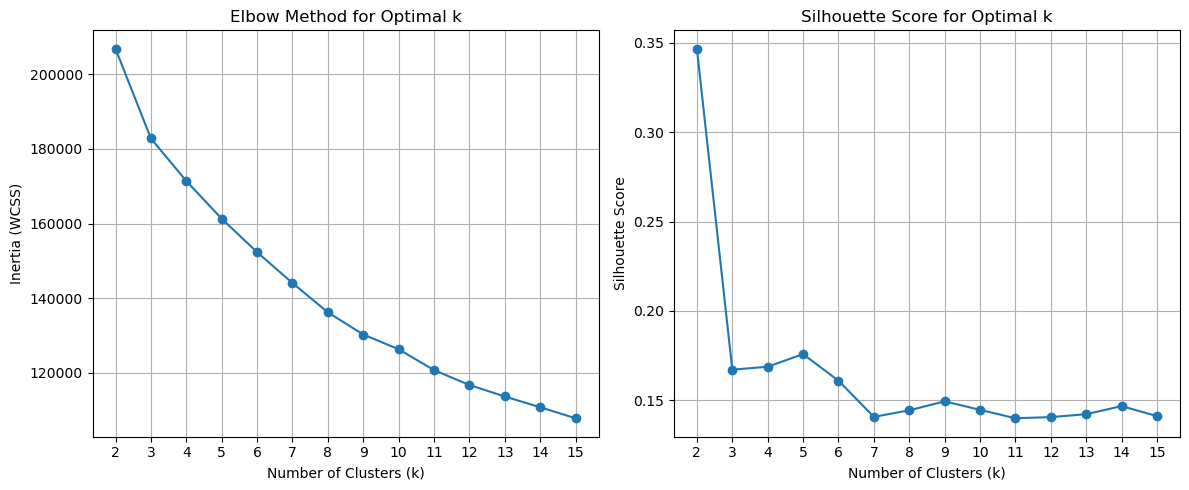

In [34]:


# --- 3. Determine Optimal Number of Clusters (k) ---

print("\nDetermining optimal k using Elbow Method and Silhouette Score...")
inertia = []
silhouette_scores = []
k_range = range(2, 16) # Test k from 2 to 15

# <<< This loop should now work >>>
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10 avoids warning, set explicitly
    kmeans.fit(X_processed) # Fit on the imputed and scaled/encoded data
    inertia.append(kmeans.inertia_)
    # Silhouette score requires at least 2 clusters
    if k > 1:
        # Make sure X_processed doesn't have NaNs before calculating silhouette
        if np.isnan(X_processed).sum() == 0:
             score = silhouette_score(X_processed, kmeans.labels_)
             silhouette_scores.append(score)
        else:
             print(f"Skipping silhouette score for k={k} due to NaNs in preprocessed data.")
             # Append a placeholder or handle as needed if NaNs persist unexpectedly
             silhouette_scores.append(np.nan) # Append NaN if calculation skipped


# Plot Elbow Method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
# Adjust k_range for silhouette plot (starts from k=2)
# Filter out potential NaNs if silhouette calculation was skipped
valid_k = [k for k, score in zip(k_range, silhouette_scores) if not np.isnan(score)]
valid_scores = [score for score in silhouette_scores if not np.isnan(score)]
if valid_k: # Only plot if there are valid scores
    plt.plot(valid_k, valid_scores, marker='o')
    plt.title('Silhouette Score for Optimal k')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.xticks(valid_k) # Use valid k values for ticks
    plt.grid(True)
else:
    plt.title('Silhouette Score (Could not be calculated)')


plt.tight_layout()
plt.show()

In [35]:

# --- 4. Apply K-Means Clustering ---

# Choose k based on the plots (e.g., where the elbow bends or silhouette score peaks)
# Let's assume k=5 is chosen based on visual inspection (adjust as needed!)
chosen_k = 5 # <<<--- ADJUST THIS BASED ON YOUR PLOTS
print(f"\nApplying K-Means with k={chosen_k}...")

kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_processed)

# Add cluster labels back to the original dataframe (before scaling/encoding)
df_clustered = df.copy() # Use the original df with index
df_clustered['cluster'] = clusters

print(f"\nAdded cluster labels to the dataframe. Cluster distribution:")
print(df_clustered['cluster'].value_counts())




Applying K-Means with k=5...

Added cluster labels to the dataframe. Cluster distribution:
cluster
2    7639
1    5449
4    3549
0    3274
3     280
Name: count, dtype: int64


In [37]:
# --- 5. Analyze Cluster Characteristics ---

print(f"\nAnalyzing characteristics of the {chosen_k} clusters...")

# Select original features (numerical and categorical) for analysis
analysis_features = numerical_features + categorical_features # Ensure these lists are correctly defined from earlier steps

# Calculate mean for numerical and mode for categorical features per cluster
cluster_analysis = df_clustered.groupby('cluster')[analysis_features].agg(
    # Apply mean to numerical columns
    **{f'{col}_mean': (col, 'mean') for col in numerical_features},
    # Apply mode (most frequent) to categorical columns
    # Mode can return multiple values if tied; we take the first one
    **{f'{col}_mode': (col, lambda x: x.mode()[0] if not x.mode().empty else None) for col in categorical_features}
)

# --- Check if 'cluster' is the index before reset ---
print(f"Index of cluster_analysis BEFORE reset_index: {cluster_analysis.index.name}")

# Reset index to make 'cluster' a column
cluster_analysis = cluster_analysis.reset_index()

# --- Check if 'cluster' is a column AFTER reset ---
print(f"Columns of cluster_analysis AFTER reset_index: {cluster_analysis.columns}")
if 'cluster' not in cluster_analysis.columns:
    raise ValueError("Critical Error: 'cluster' column not found in cluster_analysis after reset_index!")

# --- Prepare the counts dataframe robustly ---
cluster_counts_df = df_clustered['cluster'].value_counts().reset_index()

# Check the column names after reset_index (usually 'index' and 'count' or 'index' and 'cluster')
print(f"Columns of cluster_counts_df after reset_index: {cluster_counts_df.columns}")

# Define the renaming mapping dynamically
rename_map = {}
# The first column is the cluster label, rename it to 'cluster'
rename_map[cluster_counts_df.columns[0]] = 'cluster'
# The second column is the count, rename it to 'size'
rename_map[cluster_counts_df.columns[1]] = 'size'

cluster_counts_df = cluster_counts_df.rename(columns=rename_map)
print(f"Columns of cluster_counts_df AFTER rename: {cluster_counts_df.columns}")

# --- Perform the merge ---
print("Merging cluster_analysis with cluster_counts_df...")
cluster_analysis = cluster_analysis.merge(
    cluster_counts_df,
    on='cluster', # Both dataframes should now reliably have this column
    how='left' # Use left merge just in case a cluster somehow had 0 count (unlikely)
)

# --- Continue with reordering and display ---
print("Merge successful. Reordering columns...")

# Reorder columns for better readability
# Ensure 'cluster' and 'size' are present before trying to use them in cols_order
if 'cluster' in cluster_analysis.columns and 'size' in cluster_analysis.columns:
    cols_order = ['cluster', 'size'] + \
                 sorted([col for col in cluster_analysis.columns if col not in ['cluster', 'size']])
    cluster_analysis = cluster_analysis[cols_order]
else:
    print("Warning: 'cluster' or 'size' column missing after merge. Skipping reordering.")


print("\nCluster Centers (Mean/Mode of original features):")
# Displaying the analysis - might need Transpose for better viewing if many features
pd.set_option('display.max_rows', 200) # Show more rows for analysis
pd.set_option('display.max_columns', 50) # Show more columns
display(cluster_analysis.T)


Analyzing characteristics of the 5 clusters...
Index of cluster_analysis BEFORE reset_index: cluster
Columns of cluster_analysis AFTER reset_index: Index(['cluster', 'count_mean', 'sleep_time_mean_mean',
       'sleep_time_median_mean', 'wakeup_time_mean_mean',
       'wakeup_time_median_mean', 'duration_mean_mean', 'duration_median_mean',
       'satisfaction_rate_mean', 'problem_rate_mean', 'sleep_time_std_mean',
       'wakeup_time_std_mean', 'duration_std_mean', 'sleeper_type_mode',
       'duration_type_mode', 'riser_type_mode'],
      dtype='object')
Columns of cluster_counts_df after reset_index: Index(['cluster', 'count'], dtype='object')
Columns of cluster_counts_df AFTER rename: Index(['cluster', 'size'], dtype='object')
Merging cluster_analysis with cluster_counts_df...
Merge successful. Reordering columns...

Cluster Centers (Mean/Mode of original features):


,0,1,2,3,4
cluster,0,1,2,3,4
size,3274,5449,7639,280,3549
count_mean,41.649359,31.965865,33.035083,24.664286,33.06368
duration_mean_mean,7.778387,8.315799,7.304955,7.504689,7.322489
duration_median_mean,7.783616,8.343542,7.275441,7.462143,7.313215
duration_std_mean,0.909891,1.023709,1.007147,1.775371,1.222058
duration_type_mode,normal_sleep,normal_sleep,normal_sleep,normal_sleep,normal_sleep
problem_rate_mean,0.119644,0.250821,0.278357,0.241301,0.270815
riser_type_mode,early_riser,normal_riser,early_riser,early_riser,normal_riser
satisfaction_rate_mean,0.793623,0.085197,0.049321,0.391582,0.173479



Visualizing clusters using PCA (2 components)...


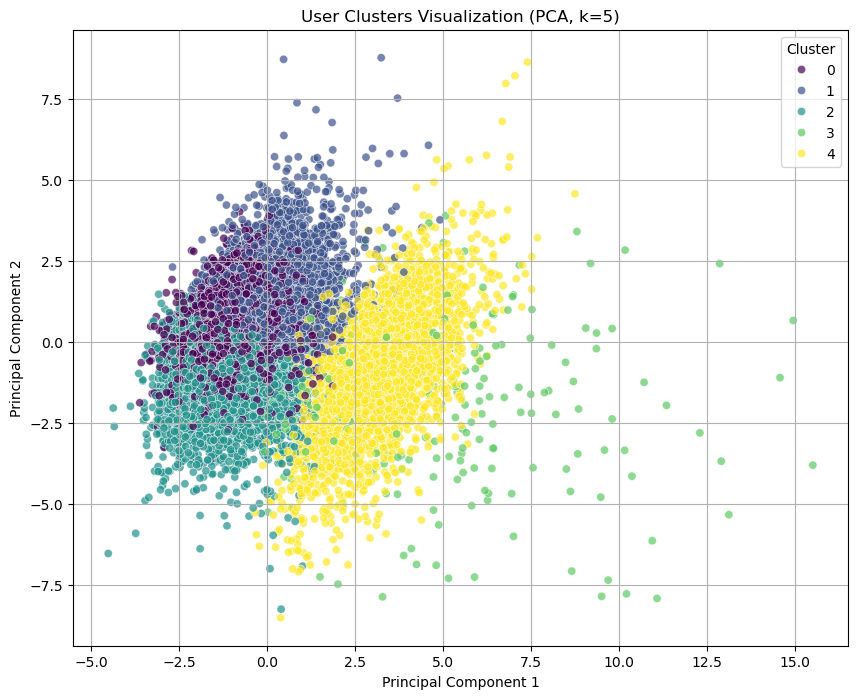


Clustering process complete.


In [38]:

# --- Optional: Visualization (using PCA) ---
print("\nVisualizing clusters using PCA (2 components)...")
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'], index=df_features.index)
df_pca['cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='cluster', palette='viridis', alpha=0.7)
plt.title(f'User Clusters Visualization (PCA, k={chosen_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print("\nClustering process complete.")


Running t-SNE for visualization (this might take a few minutes)...
Input data shape: (20191, 21)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 20191 samples in 0.000s...


/Users/vince/miniforge3/envs/ds/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 20191 samples in 0.283s...
[t-SNE] Computed conditional probabilities for sample 1000 / 20191
[t-SNE] Computed conditional probabilities for sample 2000 / 20191
[t-SNE] Computed conditional probabilities for sample 3000 / 20191
[t-SNE] Computed conditional probabilities for sample 4000 / 20191
[t-SNE] Computed conditional probabilities for sample 5000 / 20191
[t-SNE] Computed conditional probabilities for sample 6000 / 20191
[t-SNE] Computed conditional probabilities for sample 7000 / 20191
[t-SNE] Computed conditional probabilities for sample 8000 / 20191
[t-SNE] Computed conditional probabilities for sample 9000 / 20191
[t-SNE] Computed conditional probabilities for sample 10000 / 20191
[t-SNE] Computed conditional probabilities for sample 11000 / 20191
[t-SNE] Computed conditional probabilities for sample 12000 / 20191
[t-SNE] Computed conditional probabilities for sample 13000 / 20191
[t-SNE] Computed conditional probabilities for sample 14000 / 20191

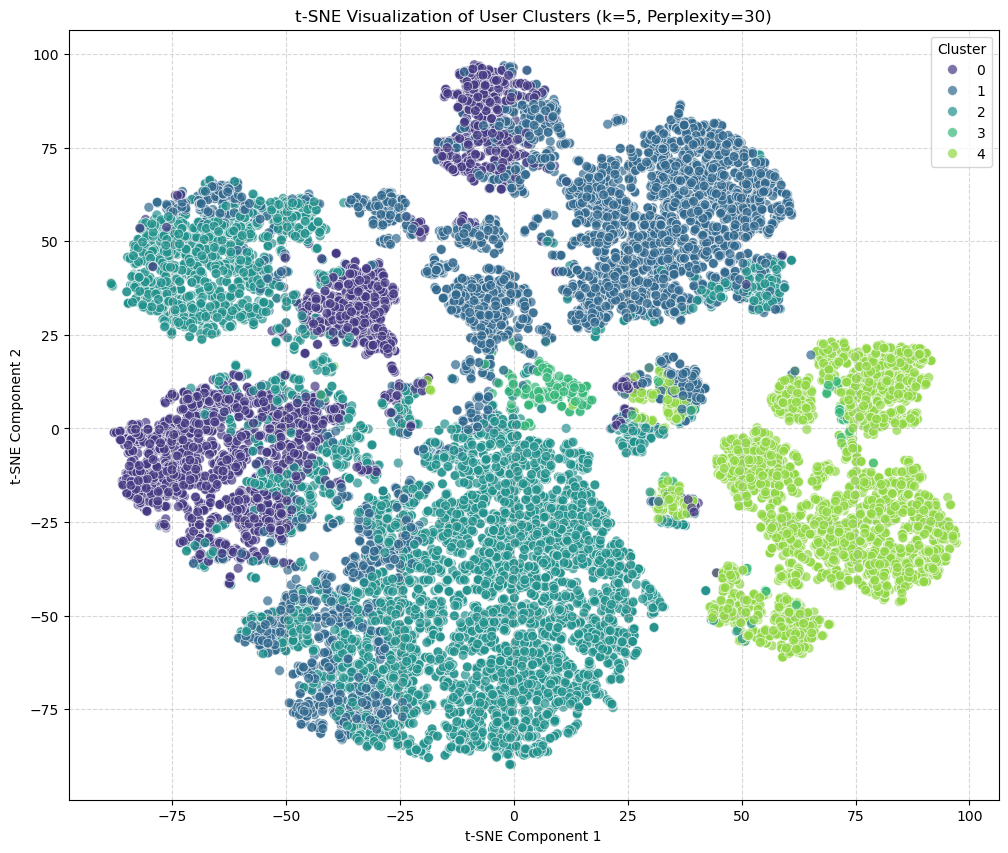


t-SNE visualization complete.
Remember: Focus on the groupings, not necessarily the distances between groups.


In [39]:
# Ensure necessary libraries are imported
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE
import time # To time the t-SNE process

# --- Check if necessary variables exist ---
if 'X_processed' not in locals():
    raise NameError("Variable 'X_processed' not defined. Please run the preprocessing steps first.")
if 'clusters' not in locals():
    raise NameError("Variable 'clusters' not defined. Please run the K-Means clustering step first.")
if 'df_features' not in locals():
     raise NameError("Variable 'df_features' not defined. Ensure feature selection step was run.")
if len(X_processed) != len(clusters):
    raise ValueError("Mismatch between length of processed data and cluster labels.")
if len(df_features) != len(clusters):
     raise ValueError("Mismatch between length of original features index and cluster labels.")


print(f"\nRunning t-SNE for visualization (this might take a few minutes)...")
print(f"Input data shape: {X_processed.shape}")

# --- Apply t-SNE ---
# Common parameters:
# n_components=2: Reduce to 2 dimensions for plotting
# perplexity: Related to number of nearest neighbors (common range: 5-50). Start with 30.
# n_iter: Number of iterations (default 1000 is often enough, can increase if needed)
# learning_rate: 'auto' is the recommended setting in recent versions.
# init='pca': Often speeds up convergence and gives more globally stable results.
# random_state: For reproducibility
tsne = TSNE(n_components=2,
            perplexity=30, # You might experiment with values like 15, 30, 50
            n_iter=1000,
            learning_rate='auto',
            init='pca',
            random_state=42,
            verbose=1) # Set verbose=1 to see progress

start_time = time.time()
X_tsne = tsne.fit_transform(X_processed)
end_time = time.time()

print(f"\nt-SNE completed in {end_time - start_time:.2f} seconds.")
print(f"t-SNE output shape: {X_tsne.shape}")

# --- Create DataFrame for Plotting ---
# Use the original index from df_features if available, otherwise just use default range
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'], index=df_features.index)
df_tsne['cluster'] = clusters # Add the cluster labels obtained from K-Means

# --- Plot t-SNE Results ---
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_tsne,
    x='TSNE1',
    y='TSNE2',
    hue='cluster',
    palette=sns.color_palette('viridis', n_colors=chosen_k), # Use 'chosen_k' clusters
    alpha=0.7, # Use transparency if points overlap
    s=50 # Adjust point size if needed
)

plt.title(f't-SNE Visualization of User Clusters (k={chosen_k}, Perplexity=30)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Cluster', loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("\nt-SNE visualization complete.")
print("Remember: Focus on the groupings, not necessarily the distances between groups.")

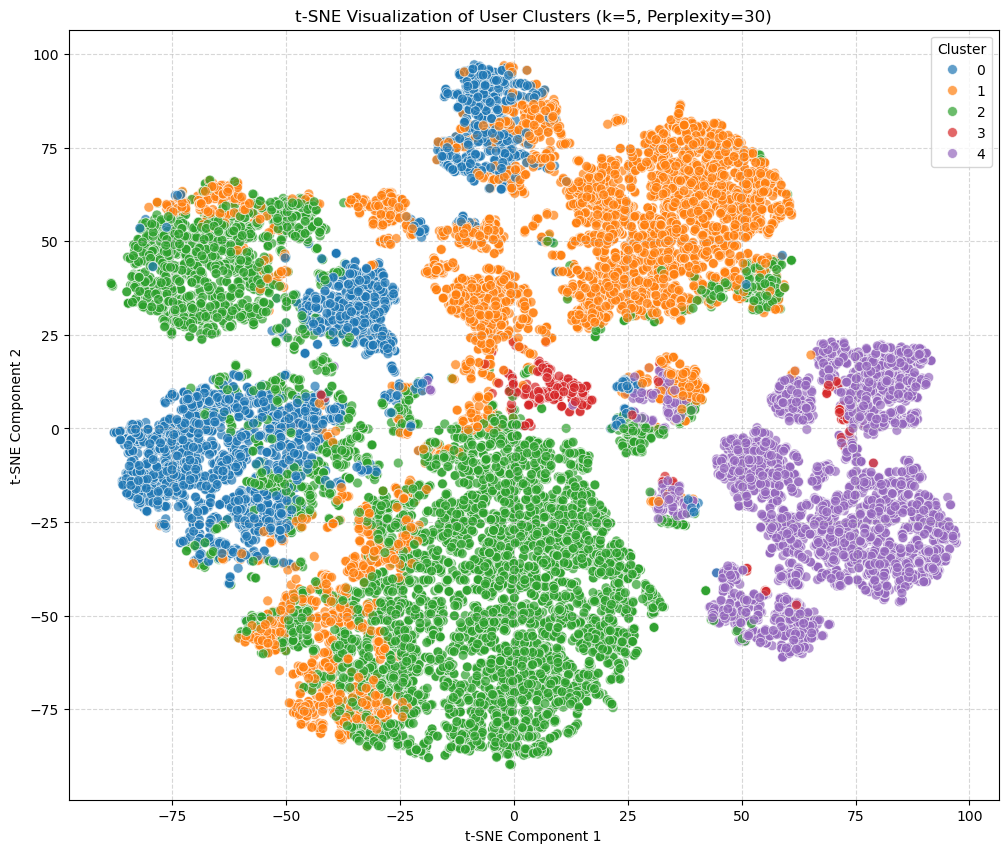


t-SNE visualization complete.
Remember: Focus on the groupings, not necessarily the distances between groups.


In [42]:
# --- Plot t-SNE Results ---
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_tsne,
    x='TSNE1',
    y='TSNE2',
    hue='cluster',
    palette=sns.color_palette('tab10', n_colors=chosen_k),
    alpha=0.7, # Use transparency if points overlap
    s=50 # Adjust point size if needed
)

plt.title(f't-SNE Visualization of User Clusters (k={chosen_k}, Perplexity=30)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Cluster', loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("\nt-SNE visualization complete.")
print("Remember: Focus on the groupings, not necessarily the distances between groups.")

In [47]:
sleep_stats_df = person_stats.merge(df_tsne.reset_index())

In [48]:
sleep_stats_df

,pid,count,sleep_time_mean,sleep_time_median,sleep_time_variance,wakeup_time_mean,wakeup_time_median,wakeup_time_variance,duration_mean,duration_median,duration_variance,satisfaction_rate,problem_rate,sleep_time_std,wakeup_time_std,duration_std,sleeper_type,duration_type,riser_type,sleep_time_mean_bucket,wakeup_time_mean_bucket,duration_mean_bucket,sleep_time_std_bucket,count_bucket,TSNE1,TSNE2,cluster
0,alqt150211047,14,23.433333,23.233333,0.918730,7.439286,7.350000,0.918958,8.005952,7.958333,1.074898,0.285714,0.714286,0.958504,0.958623,1.036773,normal_sleeper,normal_sleep,normal_riser,75-95%,50-75%,50-75%,50-75%,25-50%,14.942788,41.225395,1
1,alqt150211119,16,22.875000,22.466667,1.162292,6.576042,6.333333,0.345628,7.701042,7.916667,1.259647,0.625000,0.250000,1.078096,0.587902,1.122340,normal_sleeper,normal_sleep,early_riser,50-75%,25-50%,50-75%,75-95%,25-50%,-49.501331,-7.387415,0
2,alqt150211143,15,22.092222,22.083333,0.065699,6.275556,6.166667,0.206106,8.183333,8.083333,0.261310,0.000000,0.000000,0.256318,0.453989,0.511184,normal_sleeper,normal_sleep,early_riser,25-50%,25-50%,75-95%,Bottom 5%,25-50%,-35.780434,-79.778984,2
3,alqt150211144,14,23.696429,23.500000,1.055166,7.250000,7.500000,2.644231,7.553571,7.625000,1.617102,0.642857,0.357143,1.027213,1.626109,1.271653,normal_sleeper,normal_sleep,early_riser,75-95%,50-75%,25-50%,50-75%,25-50%,-42.058151,-2.743138,0
4,alqt150211157,25,20.222667,20.000000,0.690375,4.163333,4.000000,0.155417,7.940667,8.000000,1.069909,0.920000,0.080000,0.830888,0.394229,1.034364,early_sleeper,normal_sleep,early_riser,5-25%,Bottom 5%,50-75%,50-75%,50-75%,-37.747482,28.967926,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20186,alqt230542245394,19,23.293860,22.833333,1.131410,7.016667,7.666667,3.502377,7.722807,8.533333,4.886519,0.105263,0.578947,1.063677,1.871464,2.210547,normal_sleeper,long_sleep,normal_riser,75-95%,50-75%,50-75%,75-95%,25-50%,29.298395,33.381298,1
20187,alqt230845254234,6,0.172222,23.875000,1.771914,6.627778,6.883333,1.040963,6.455556,6.658333,1.921741,0.000000,0.166667,1.331132,1.020276,1.386269,normal_sleeper,normal_sleep,early_riser,Bottom 5%,25-50%,5-25%,75-95%,5-25%,26.192598,-0.690461,2
20188,alqt230856254132,16,23.590625,23.416667,0.358541,6.997917,6.083333,3.151588,7.407292,6.833333,2.112962,0.000000,0.125000,0.598783,1.775271,1.453603,normal_sleeper,normal_sleep,early_riser,75-95%,50-75%,25-50%,25-50%,25-50%,4.488849,-4.821686,2
20189,alqt230857254072,6,23.519444,23.141667,2.320872,6.436111,6.408333,0.145935,6.916667,7.258333,3.004444,0.000000,0.666667,1.523441,0.382015,1.733333,normal_sleeper,normal_sleep,early_riser,75-95%,25-50%,5-25%,75-95%,5-25%,-6.012525,-8.248017,2


In [49]:

# --- 4. Apply K-Means Clustering ---

# Choose k based on the plots (e.g., where the elbow bends or silhouette score peaks)
# Let's assume k=5 is chosen based on visual inspection (adjust as needed!)
chosen_k = 2 # <<<--- ADJUST THIS BASED ON YOUR PLOTS
print(f"\nApplying K-Means with k={chosen_k}...")

kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_processed)

# Add cluster labels back to the original dataframe (before scaling/encoding)
df_clustered = df.copy() # Use the original df with index
df_clustered['cluster'] = clusters

print(f"\nAdded cluster labels to the dataframe. Cluster distribution:")
print(df_clustered['cluster'].value_counts())




Applying K-Means with k=2...

Added cluster labels to the dataframe. Cluster distribution:
cluster
0    16201
1     3990
Name: count, dtype: int64


In [50]:
# --- 5. Analyze Cluster Characteristics ---

print(f"\nAnalyzing characteristics of the {chosen_k} clusters...")

# Select original features (numerical and categorical) for analysis
analysis_features = numerical_features + categorical_features # Ensure these lists are correctly defined from earlier steps

# Calculate mean for numerical and mode for categorical features per cluster
cluster_analysis = df_clustered.groupby('cluster')[analysis_features].agg(
    # Apply mean to numerical columns
    **{f'{col}_mean': (col, 'mean') for col in numerical_features},
    # Apply mode (most frequent) to categorical columns
    # Mode can return multiple values if tied; we take the first one
    **{f'{col}_mode': (col, lambda x: x.mode()[0] if not x.mode().empty else None) for col in categorical_features}
)

# --- Check if 'cluster' is the index before reset ---
print(f"Index of cluster_analysis BEFORE reset_index: {cluster_analysis.index.name}")

# Reset index to make 'cluster' a column
cluster_analysis = cluster_analysis.reset_index()

# --- Check if 'cluster' is a column AFTER reset ---
print(f"Columns of cluster_analysis AFTER reset_index: {cluster_analysis.columns}")
if 'cluster' not in cluster_analysis.columns:
    raise ValueError("Critical Error: 'cluster' column not found in cluster_analysis after reset_index!")

# --- Prepare the counts dataframe robustly ---
cluster_counts_df = df_clustered['cluster'].value_counts().reset_index()

# Check the column names after reset_index (usually 'index' and 'count' or 'index' and 'cluster')
print(f"Columns of cluster_counts_df after reset_index: {cluster_counts_df.columns}")

# Define the renaming mapping dynamically
rename_map = {}
# The first column is the cluster label, rename it to 'cluster'
rename_map[cluster_counts_df.columns[0]] = 'cluster'
# The second column is the count, rename it to 'size'
rename_map[cluster_counts_df.columns[1]] = 'size'

cluster_counts_df = cluster_counts_df.rename(columns=rename_map)
print(f"Columns of cluster_counts_df AFTER rename: {cluster_counts_df.columns}")

# --- Perform the merge ---
print("Merging cluster_analysis with cluster_counts_df...")
cluster_analysis = cluster_analysis.merge(
    cluster_counts_df,
    on='cluster', # Both dataframes should now reliably have this column
    how='left' # Use left merge just in case a cluster somehow had 0 count (unlikely)
)

# --- Continue with reordering and display ---
print("Merge successful. Reordering columns...")

# Reorder columns for better readability
# Ensure 'cluster' and 'size' are present before trying to use them in cols_order
if 'cluster' in cluster_analysis.columns and 'size' in cluster_analysis.columns:
    cols_order = ['cluster', 'size'] + \
                 sorted([col for col in cluster_analysis.columns if col not in ['cluster', 'size']])
    cluster_analysis = cluster_analysis[cols_order]
else:
    print("Warning: 'cluster' or 'size' column missing after merge. Skipping reordering.")


print("\nCluster Centers (Mean/Mode of original features):")
# Displaying the analysis - might need Transpose for better viewing if many features
pd.set_option('display.max_rows', 200) # Show more rows for analysis
pd.set_option('display.max_columns', 50) # Show more columns
display(cluster_analysis.T)


Analyzing characteristics of the 2 clusters...
Index of cluster_analysis BEFORE reset_index: cluster
Columns of cluster_analysis AFTER reset_index: Index(['cluster', 'count_mean', 'sleep_time_mean_mean',
       'sleep_time_median_mean', 'wakeup_time_mean_mean',
       'wakeup_time_median_mean', 'duration_mean_mean', 'duration_median_mean',
       'satisfaction_rate_mean', 'problem_rate_mean', 'sleep_time_std_mean',
       'wakeup_time_std_mean', 'duration_std_mean', 'sleeper_type_mode',
       'duration_type_mode', 'riser_type_mode'],
      dtype='object')
Columns of cluster_counts_df after reset_index: Index(['cluster', 'count'], dtype='object')
Columns of cluster_counts_df AFTER rename: Index(['cluster', 'size'], dtype='object')
Merging cluster_analysis with cluster_counts_df...
Merge successful. Reordering columns...

Cluster Centers (Mean/Mode of original features):


,0,1
cluster,0,1
size,16201,3990
count_mean,34.448676,32.341604
duration_mean_mean,7.739178,7.3404
duration_median_mean,7.734127,7.335343
duration_std_mean,0.991686,1.258674
duration_type_mode,normal_sleep,normal_sleep
problem_rate_mean,0.237209,0.268289
riser_type_mode,early_riser,normal_riser
satisfaction_rate_mean,0.210714,0.188186


In [55]:
tmp_df = df_clustered['cluster'].reset_index()
tmp_df = tmp_df.rename(columns={'cluster': 'k2_cluster'})

In [57]:
sleep_stats_df = sleep_stats_df.merge(tmp_df)

In [58]:
sleep_stats_df.to_csv('sleep_stats_df.csv')